In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [26]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [27]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [28]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [29]:
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town']=df['embark_town'].fillna(df['embark_town'].mode()[0])

df.drop('deck',inplace=True,axis=1)

In [30]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(116)

In [32]:
df.drop_duplicates(inplace=True)

In [33]:
df.duplicated().sum()

np.int64(0)

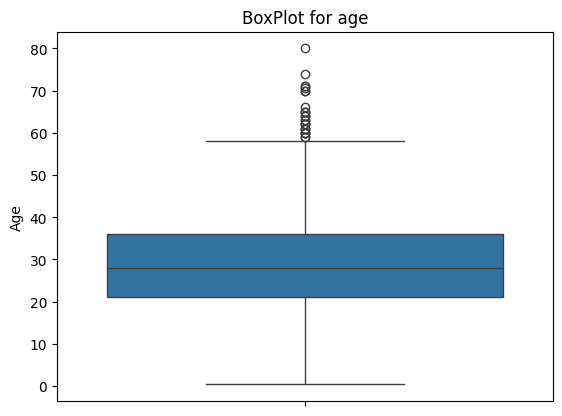

0.44198678493510685


In [34]:
# • Plot boxplot for numeric feature 

plt.figure()
sns.boxplot(y=df['age'])
plt.title('BoxPlot for age')
plt.ylabel("Age")
plt.show()

# Age distribution is slightly right-skewed
print(df['age'].skew())

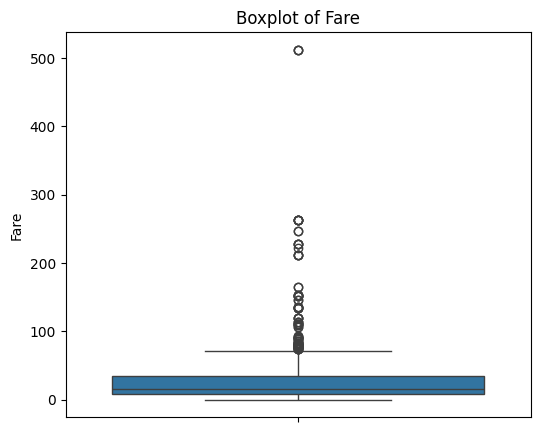

4.549950352869661


In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df['fare'])
plt.title("Boxplot of Fare")
plt.ylabel("Fare")
plt.show()


# Fare is highly right-skewed
print(df['fare'].skew())

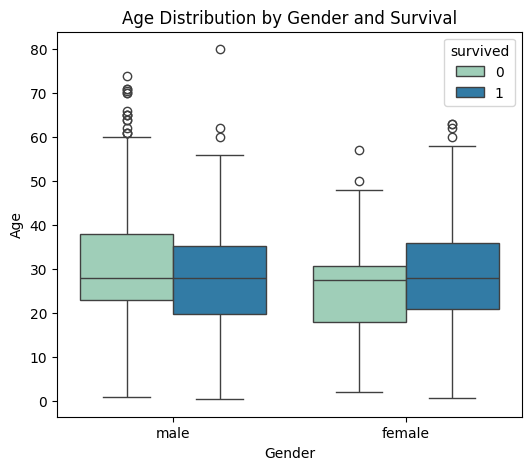

In [36]:
# Boxplot: Age vs Gender vs Survival

plt.figure(figsize=(6,5))
sns.boxplot( x='sex',y='age',hue='survived',data=df,palette='YlGnBu')
plt.title("Age Distribution by Gender and Survival")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()

In [37]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower limit",lower)
print("Upper limit",upper)

outliers_age = df[(df['age'] < lower) | (df['age'] > upper)]
print("\nNumber of Outliers in Age:", len(outliers_age))

print("Age Outliers:\n", outliers_age['age']) # This output shows row indices and age values of passengers 
                                                # that are considered outliers.

Lower limit -1.5
Upper limit 58.5

Number of Outliers in Age: 27
Age Outliers:
 33     66.0
54     65.0
94     59.0
96     71.0
116    70.5
170    61.0
232    59.0
252    62.0
275    63.0
280    65.0
326    61.0
366    60.0
438    64.0
456    65.0
483    63.0
493    71.0
545    64.0
570    62.0
587    60.0
625    61.0
630    80.0
672    70.0
684    60.0
694    60.0
745    70.0
829    62.0
851    74.0
Name: age, dtype: float64
